In [55]:
pip install geopandas


[notice] A new release of pip is available: 24.0 -> 25.2
[notice] To update, run: pip3.12 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [56]:
pip install --upgrade nbformat


[notice] A new release of pip is available: 24.0 -> 25.2
[notice] To update, run: pip3.12 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [57]:
pip install plotly


[notice] A new release of pip is available: 24.0 -> 25.2
[notice] To update, run: pip3.12 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [58]:
pip install matplotlib


[notice] A new release of pip is available: 24.0 -> 25.2
[notice] To update, run: pip3.12 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [59]:
pip install seaborn


[notice] A new release of pip is available: 24.0 -> 25.2
[notice] To update, run: pip3.12 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [60]:
import geopandas as gpd
import plotly.express as px
import pandas as pd
import json
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [61]:
folder_path = "data_raw/shapefiles/historicalcounties"
pre_map_df = gpd.read_file(folder_path)
pre_map_df.rename(columns={'NHGISNAM': 'county'}, inplace=True)
pre_map_df.rename(columns={'STATENAM': 'state'}, inplace=True)

['ID', 'ID2', 'OBJECTID', 'GISJOIN', 'DECADE', 'county', 'NHGISST', 'NHGISCTY', 'ICPSRST', 'ICPSRCTY', 'ICPSRNAM', 'state', 'SHAPE_AREA', 'SHAPE_LEN', 'AreaI', 'Geo_FIPS', 'geometry', 'population']


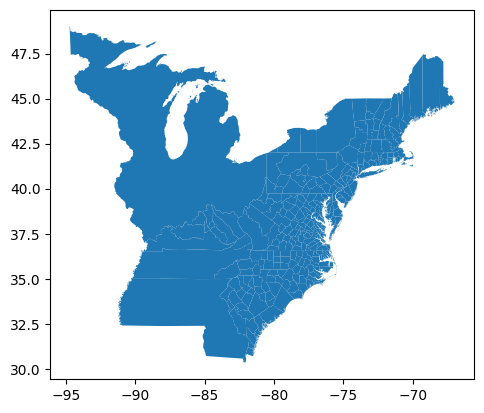

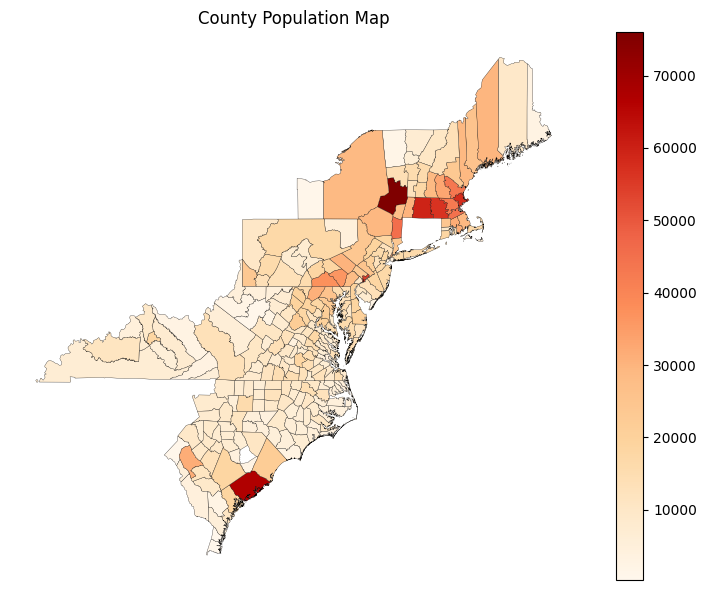

In [84]:
pre_map_df["geometry"] = pre_map_df["geometry"].simplify(0.01).buffer(0)

pre_map_df.plot()

pre_map_str = pre_map_df.to_json()
pre_map_gj = json.loads(pre_map_str)

county_pops = pd.read_csv("data_raw/census_data/countyPopulation.csv", header=1)
county_pops = county_pops[county_pops["SE_T001_001"].notna()]
county_pops = county_pops.astype({"SE_T001_001": "int", "Geo_FIPS": "str"})
county_pops = county_pops[["Geo_FIPS", "SE_T001_001"]]
county_pops.rename(columns={'SE_T001_001': 'population'}, inplace=True)
county_pops['Geo_FIPS'] = county_pops['Geo_FIPS'].astype(str).str.zfill(5)
pre_map_df['Geo_FIPS'] = pre_map_df['Geo_FIPS'].astype(str).str.zfill(5)

pre_map_df = pre_map_df.merge(county_pops, on='Geo_FIPS', how='left')

pre_map_df.plot(
    column='population',
    cmap='OrRd',
    legend=True,
    edgecolor='black',
    linewidth=0.2,
    figsize=(8, 6)
)

plt.title("County Population Map")
plt.axis('off')
plt.tight_layout()
plt.show()

/var/folders/3f/77w9tyf13fvfq2c4rg1tp9x40000gn/T/ipykernel_77835/1416611594.py:1: DtypeWarning:

Columns (1,10,12,13,17,18,23,30) have mixed types. Specify dtype option on import or set low_memory=False.



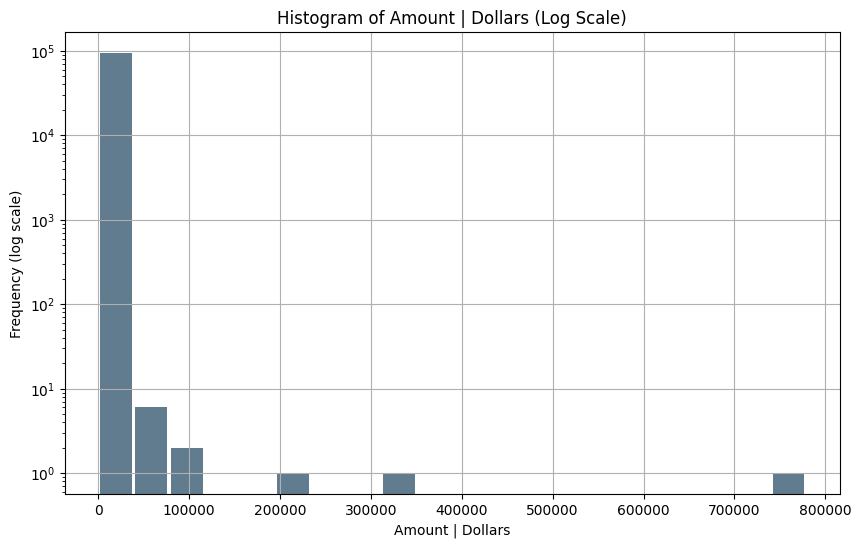

(array([10301]),)


/var/folders/3f/77w9tyf13fvfq2c4rg1tp9x40000gn/T/ipykernel_77835/1416611594.py:19: DtypeWarning:

Columns (1,10,12,13,17,18,23,30) have mixed types. Specify dtype option on import or set low_memory=False.



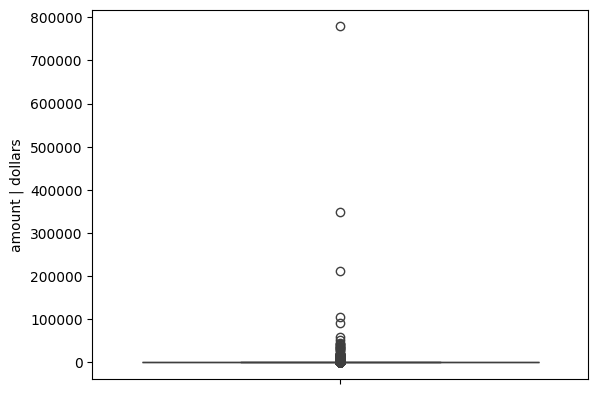

In [85]:
pre_debt_by_state = pd.read_csv("cleaning_CD/pre1790/data/agg_debt_david.csv")[["state", "amount | dollars"]]
pre_debt_by_state["amount | dollars"] = pd.to_numeric(pre_debt_by_state["amount | dollars"], errors="coerce")

filtered_debt = pre_debt_by_state[
    pre_debt_by_state["amount | dollars"].between(
        pre_debt_by_state["amount | dollars"].quantile(0.15),
        pre_debt_by_state["amount | dollars"].quantile(0.85)
    )
]

plt.figure(figsize=(10,6))
pre_debt_by_state["amount | dollars"].plot.hist(bins=20, grid=True, rwidth=0.9, color="#607c8e", log=True)
plt.title("Histogram of Amount | Dollars (Log Scale)")
plt.xlabel("Amount | Dollars")
plt.ylabel("Frequency (log scale)")
plt.show()

#OUTLIERS:
pre_debt_by_state_full = pd.read_csv("cleaning_CD/pre1790/data/agg_debt_david.csv")[["state", "amount | dollars"]]
pre_debt_by_state.columns = pre_debt_by_state.columns
pre_debt_by_state.columns = ["state", "amount | dollars"]
pre_debt_by_state["amount | dollars"]
sns.boxplot(pre_debt_by_state["amount | dollars"])
print(np.where(pre_debt_by_state["amount | dollars"]>(0.5 * 1000000)))
